In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mendefinisikan jalur file data mentah
DATA_PATH = "../namadataset_raw/raw_data.csv"

# Memuat dataset ke dalam DataFrame pandas
df = pd.read_csv(DATA_PATH)
print(f"[+] Berhasil memuat data. Total baris: {df.shape[0]}, Total kolom: {df.shape[1]}")
df.head()

[+] Berhasil memuat data. Total baris: 45000, Total kolom: 14


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
# Memeriksa tipe data dari setiap kolom dan struktur dataset
print("=== Struktur Informasi Dataset ===")
df.info()

# Memeriksa statistik deskriptif untuk fitur numerik
print("\n=== Statistik Deskriptif ===")
df.describe().T

=== Struktur Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 1

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [3]:
# Memeriksa jumlah data kosong (missing values)
print("=== Jumlah Missing Values ===")
print(df.isnull().sum())

# Memeriksa jumlah baris data yang duplikat
print(f"\n[!] Jumlah data duplikat: {df.duplicated().sum()}")

=== Jumlah Missing Values ===
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

[!] Jumlah data duplikat: 0


=== Distribusi Target (Loan Status) ===
loan_status
0    35000
1    10000
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18232\3668113660.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


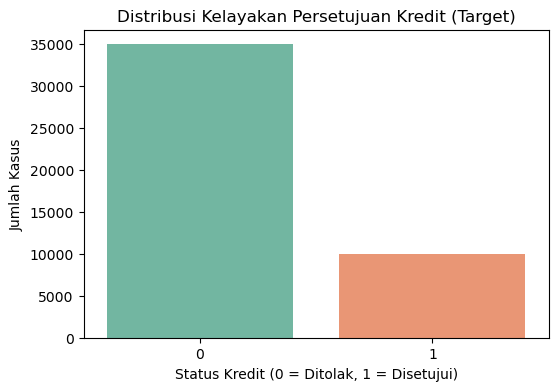

In [4]:
# Memeriksa distribusi variabel target (loan_status) untuk melihat keseimbangan kelas
target_counts = df['loan_status'].value_counts()
print("=== Distribusi Target (Loan Status) ===")
print(target_counts)

# Menampilkan visualisasi sederhana distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('Distribusi Kelayakan Persetujuan Kredit (Target)')
plt.xlabel('Status Kredit (0 = Ditolak, 1 = Disetujui)')
plt.ylabel('Jumlah Kasus')
plt.show()

In [5]:
# 1. Menghapus data duplikat jika ditemukan
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("[+] Data duplikat berhasil dihapus.")

# 2. Mengisi missing values pada fitur numerik dengan nilai median kolom masing-masing
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 3. Mengisi missing values pada fitur kategorikal dengan nilai modus
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("[+] Pembersihan missing values selesai dilakukan.")
print("Sisa missing values:\n", df.isnull().sum().sum())

[+] Pembersihan missing values selesai dilakukan.
Sisa missing values:
 0


In [6]:
# Mengubah variabel teks (kategorikal) menjadi angka agar bisa diproses algoritma Machine Learning
print("Kolom kategorikal sebelum encoding:", list(categorical_cols))

# Melakukan One-Hot Encoding untuk fitur-fitur kategori
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Memastikan seluruh tipe data hasil get_dummies diubah ke integer/float (bukan boolean)
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

print("\nDimensi dataset setelah dilakukan One-Hot Encoding:", df_encoded.shape)
df_encoded.head()

Kolom kategorikal sebelum encoding: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

Dimensi dataset setelah dilakukan One-Hot Encoding: (45000, 23)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,1,0,0,1,0,0,0,1,0,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,1,0,1,0,0,0,0,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,0,0,0,0,1,0,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,...,0,0,0,1,0,0,1,0,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,1,...,1,0,0,1,0,0,1,0,0,0


In [7]:
# Mendefinisikan direktori output untuk data hasil preprocessing
OUTPUT_DIR = "namadataset_preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(OUTPUT_DIR, "clean_data.csv")
df_encoded.to_csv(OUTPUT_PATH, index=False)
print(f"[+] Eksperimen manual sukses. File bersih disimpan di: preprocessing/{OUTPUT_PATH}")

[+] Eksperimen manual sukses. File bersih disimpan di: preprocessing/namadataset_preprocessing\clean_data.csv
